# PA3: prova de conceito do recomendador

Prova de conceito de recomendação por conteúdo: TF-IDF sobre a sinopse (`Overview`) e similaridade de cosseno, com Top 5. É uma primeira versão, sem ajuste de parâmetros; refinamentos pertencem a uma etapa posterior.

Estudos sobre recomendação de filmes já analisaram enredos com TF-IDF ([Iliopoulou et al., 2020](https://doi.org/10.1007/978-3-030-49190-1_17)) e sinopses com TF-IDF e cosseno ([Permana e Wibowo, 2023](https://doi.org/10.21108/ijoict.v9i2.747)). Eles ajudam a justificar a escolha da representação textual, mas usam outras bases e outras formas de avaliação. Os resultados deles não são usados como resultado deste notebook.

**Atenção sobre a avaliação.** A base não tem dados de usuários. Nesta prova de conceito, a avaliação adotada é um **indicador proxy indireto**: sobreposição de gêneros entre o filme consultado e os recomendados. Ela **não prova** que as recomendações sejam relevantes para pessoas.

In [1]:
from pathlib import Path
import sys

def localizar_raiz(inicio=None):
    """Sobe a partir do diretório atual até achar data/raw/imdb_top_1000.csv."""
    inicio = Path(inicio or Path.cwd()).resolve()
    for pasta in [inicio, *inicio.parents]:
        if (pasta / "data" / "raw" / "imdb_top_1000.csv").is_file():
            return pasta
    raise FileNotFoundError("data/raw/imdb_top_1000.csv não encontrado acima de "
                            f"{inicio}. Consulte data/README.md para obter o CSV.")

ROOT = localizar_raiz()
sys.path.insert(0, str(ROOT / "src"))
CSV_BRUTO = ROOT / "data" / "raw" / "imdb_top_1000.csv"
print("Raiz do projeto localizada; CSV bruto:", CSV_BRUTO.relative_to(ROOT))

Raiz do projeto localizada; CSV bruto: data/raw/imdb_top_1000.csv


## 1. Protocolo definido antes de calcular

| Item | Definição |
|---|---|
| Entrada do modelo | Somente `Overview` (TF-IDF, `stop_words="english"`, demais parâmetros padrão do scikit-learn). Gênero, ano, nota e votos **não** entram no modelo. Nada mais é incluído, para manter a prova de conceito simples e atribuir qualquer resultado à sinopse. |
| K | 5 |
| Consultas | Os 1000 filmes, um de cada vez (identificados por `film_id`). |
| Conjunto de candidatos | Os outros 999 filmes: a consulta é sempre excluída (leave-the-query-out). |
| Desempate (conteúdo) | Maior similaridade; depois ano de lançamento mais antigo (ausente por último); depois menor `film_id`. |
| Linha de base de popularidade | Os 5 filmes com mais `No_of_Votes` entre os candidatos (mesma lista para todas as consultas, exceto quando a consulta está entre eles). |
| Linha de base aleatória | 5 candidatos sorteados sem reposição, `numpy.random.default_rng(42)`, uma sequência contínua sobre as consultas em ordem de `film_id`. Estabilidade verificada também com as sementes 0 a 19. |
| Regra de relevância proxy | Um recomendado é "relevante pelo proxy" se compartilha **pelo menos um gênero** com a consulta. |
| Métrica principal | Precisão proxy@5 = fração dos 5 recomendados relevantes pelo proxy, média sobre as 1000 consultas. |
| Métricas auxiliares | Jaccard médio de gêneros@5 e cobertura (filmes distintos recomendados / 1000). |
| Referência de taxa-base | Valor esperado da precisão proxy@5 se os 5 fossem sorteados ao acaso (calculado exatamente). |

Limitação conhecida da regra: Drama está em 72,4% dos filmes, então a taxa-base é alta e a regra é permissiva. Por isso comparamos com a linha aleatória e com a taxa-base, em vez de ler o valor absoluto.

In [2]:
import json, platform, time
import numpy as np
import pandas as pd
import matplotlib, matplotlib.pyplot as plt
import sklearn
from recomendador import (K, matriz_similaridade, ranking_conteudo, ranking_popularidade,
                          ranking_aleatorio, conjunto_generos, metricas_proxy)

FIG = ROOT / "reports" / "figures"; MET = ROOT / "reports" / "metrics"
FIG.mkdir(parents=True, exist_ok=True); MET.mkdir(parents=True, exist_ok=True)
SEMENTE = 42
SEMENTES_ESTABILIDADE = list(range(20))

filmes = pd.read_csv(ROOT / "data" / "processed" / "filmes_preparados.csv")
filmes["Released_Year"] = filmes["Released_Year"].astype("Int64")
assert len(filmes) == 1000 and (filmes["film_id"] == np.arange(1000)).all()
N = len(filmes)
G = conjunto_generos(filmes["Genre"])      # usado SOMENTE na avaliação
print("Filmes:", N, "| K =", K)

Filmes: 1000 | K = 5


## 2. Modelo: TF-IDF sobre a sinopse

Vetorização de `Overview` e matriz de similaridade de cosseno 1000 x 1000.

In [3]:
t0 = time.perf_counter()
X, SIM, vetor = matriz_similaridade(filmes["Overview"])
t_modelo = time.perf_counter() - t0
print("Matriz TF-IDF:", X.shape, "| termos no vocabulário:", len(vetor.vocabulary_))
print("Densidade da matriz esparsa: %.2f%%" % (100 * X.nnz / (X.shape[0] * X.shape[1])))
sem_termos = int((X.getnnz(axis=1) == 0).sum())
print("Filmes sem nenhum termo após stop words:", sem_termos)
off = SIM[~np.eye(N, dtype=bool)]
print("Similaridade entre pares distintos: mín %.3f | mediana %.3f | máx %.3f" % (off.min(), np.median(off), off.max()))
print("Pares distintos com similaridade 0:", f"{(off == 0).mean():.1%}")

Matriz TF-IDF: (1000, 5426) | termos no vocabulário: 5426
Densidade da matriz esparsa: 0.25%
Filmes sem nenhum termo após stop words: 0
Similaridade entre pares distintos: mín 0.000 | mediana 0.000 | máx 0.510
Pares distintos com similaridade 0: 86.5%


## 3. Recomendações Top 5 para todas as consultas

Calcula, para cada filme como consulta, os três rankings e as métricas proxy.

In [4]:
ano = filmes["Released_Year"].astype(float).to_numpy()
votos = filmes["No_of_Votes"].to_numpy()

def rodar_aleatorio(semente):
    rng = np.random.default_rng(semente)
    return [ranking_aleatorio(N, i, rng) for i in range(N)]

rankings = {
    "tfidf_sinopse": [ranking_conteudo(SIM, ano, i) for i in range(N)],
    "popularidade": [ranking_popularidade(votos, i) for i in range(N)],
    "aleatorio": rodar_aleatorio(SEMENTE),
}
# Garantias do protocolo
for nome, recs in rankings.items():
    assert all(len(r) == K and i not in r and len(set(r)) == K for i, r in enumerate(recs)), nome

linhas = []
for nome, recs in rankings.items():
    for i, r in enumerate(recs):
        p, j = metricas_proxy(G, i, r)
        linhas.append({"film_id": i, "metodo": nome, "precisao_proxy_5": p, "jaccard_5": j})
por_consulta = pd.DataFrame(linhas)
por_consulta.head()

,film_id,metodo,precisao_proxy_5,jaccard_5
0,0,tfidf_sinopse,1.0,0.400000
1,1,tfidf_sinopse,1.0,0.500000
2,2,tfidf_sinopse,1.0,0.450000
3,3,tfidf_sinopse,1.0,0.566667
4,4,tfidf_sinopse,0.6,0.283333


In [5]:
def taxa_base_exata():
    """Esperado da precisão proxy@5 para sorteio uniforme entre os 999 candidatos."""
    vals = []
    for i in range(N):
        c = [len(G[i] & G[j]) > 0 for j in range(N) if j != i]
        vals.append(np.mean(c))
    return float(np.mean(vals))

def resumo(nome):
    d = por_consulta[por_consulta["metodo"] == nome]
    distintos = len({j for r in rankings[nome] for j in r})
    return {"metodo": nome, "k": K, "n_consultas": len(d),
            "precisao_proxy_media": round(d["precisao_proxy_5"].mean(), 4),
            "erro_padrao": round(d["precisao_proxy_5"].std(ddof=1) / np.sqrt(len(d)), 4),
            "jaccard_medio": round(d["jaccard_5"].mean(), 4),
            "filmes_distintos_recomendados": distintos,
            "cobertura_catalogo": round(distintos / N, 4)}

metricas = pd.DataFrame([resumo(m) for m in rankings])
TAXA_BASE = taxa_base_exata()
print(metricas.to_string(index=False))
print("\nTaxa-base exata (sorteio uniforme), precisão proxy@5: %.4f" % TAXA_BASE)

       metodo  k  n_consultas  precisao_proxy_media  erro_padrao  jaccard_medio  filmes_distintos_recomendados  cobertura_catalogo
tfidf_sinopse  5         1000                0.7688       0.0080         0.2993                            952               0.952
 popularidade  5         1000                0.6822       0.0091         0.2705                              6               0.006
    aleatorio  5         1000                0.6612       0.0090         0.2136                            995               0.995

Taxa-base exata (sorteio uniforme), precisão proxy@5: 0.6616


### Estabilidade da linha aleatória e diferenças por consulta
O sorteio muda com a semente. As sementes 0 a 19 mostram quanto a linha aleatória varia. Para o TF-IDF contra a popularidade, o desvio por consulta indica a dispersão, sem pretender ser um teste de hipótese.

In [6]:
est = []
for s in SEMENTES_ESTABILIDADE:
    recs = rodar_aleatorio(s)
    est.append(np.mean([metricas_proxy(G, i, r)[0] for i, r in enumerate(recs)]))
est = np.array(est)
print("Aleatório, precisão proxy@5 em 20 sementes: média %.4f | desvio %.4f | mín %.4f | máx %.4f" % (est.mean(), est.std(ddof=1), est.min(), est.max()))

p = por_consulta.pivot(index="film_id", columns="metodo", values="precisao_proxy_5")
print("TF-IDF > popularidade em %d consultas | empate em %d | menor em %d" % ((p.tfidf_sinopse > p.popularidade).sum(), (p.tfidf_sinopse == p.popularidade).sum(), (p.tfidf_sinopse < p.popularidade).sum()))
print("TF-IDF > aleatório   em %d consultas | empate em %d | menor em %d" % ((p.tfidf_sinopse > p.aleatorio).sum(), (p.tfidf_sinopse == p.aleatorio).sum(), (p.tfidf_sinopse < p.aleatorio).sum()))
print("Consultas com precisão proxy 0 (nenhum recomendado compartilha gênero):", {m: int((p[m] == 0).sum()) for m in p.columns})

Aleatório, precisão proxy@5 em 20 sementes: média 0.6620 | desvio 0.0038 | mín 0.6536 | máx 0.6696
TF-IDF > popularidade em 463 consultas | empate em 366 | menor em 171
TF-IDF > aleatório   em 495 consultas | empate em 299 | menor em 206
Consultas com precisão proxy 0 (nenhum recomendado compartilha gênero): {'aleatorio': 50, 'popularidade': 74, 'tfidf_sinopse': 20}


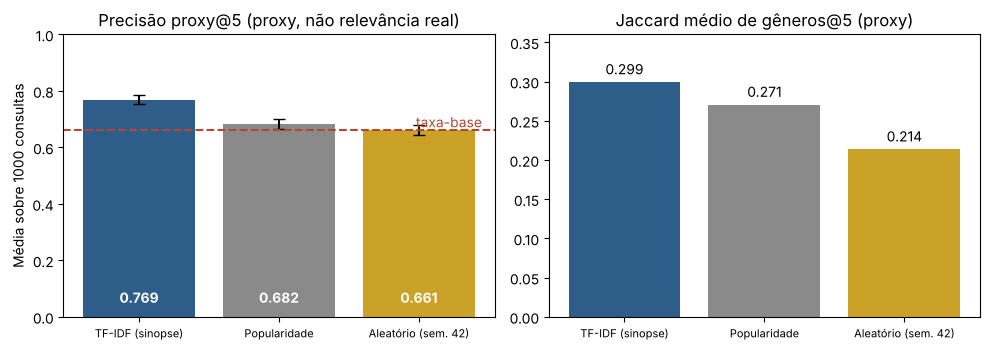

In [7]:
rot = {"tfidf_sinopse": "TF-IDF (sinopse)", "popularidade": "Popularidade", "aleatorio": "Aleatório (sem. 42)"}
cores = ["#2F5D8A", "#8A8A8A", "#C9A227"]
fig, axs = plt.subplots(1, 2, figsize=(10, 3.6))
v = metricas.set_index("metodo")
axs[0].bar([rot[m] for m in v.index], v["precisao_proxy_media"], yerr=1.96 * v["erro_padrao"], color=cores, capsize=4)
axs[0].axhline(TAXA_BASE, color="#B5472F", ls="--"); axs[0].text(2.45, TAXA_BASE + 0.01, "taxa-base", color="#B5472F", ha="right")
for x, val in enumerate(v["precisao_proxy_media"]): axs[0].text(x, 0.05, f"{val:.3f}", ha="center", color="white", fontweight="bold")
axs[0].set_ylim(0, 1); axs[0].set_title("Precisão proxy@5 (proxy, não relevância real)"); axs[0].set_ylabel("Média sobre 1000 consultas")
axs[1].bar([rot[m] for m in v.index], v["jaccard_medio"], color=cores)
for x, val in enumerate(v["jaccard_medio"]): axs[1].text(x, val + 0.01, f"{val:.3f}", ha="center")
axs[1].set_ylim(0, 0.36); axs[1].set_title("Jaccard médio de gêneros@5 (proxy)")
for a in axs: a.tick_params(axis="x", labelsize=8)
fig.tight_layout(); fig.savefig(FIG / "metricas_proxy_comparacao.png"); plt.show()

### Leitura das métricas (proxy)
- A precisão proxy@5 do TF-IDF é maior que a da linha aleatória e que a taxa-base; a linha aleatória fica em torno da taxa-base, como esperado. A diferença entre TF-IDF e aleatório é de aproximadamente 0,11 ponto de proporção, bem acima do erro padrão (cerca de 0,01) e da variação entre sementes (desvio cerca de 0,004).
- A popularidade fica pouco acima da taxa-base porque os filmes mais votados são majoritariamente Drama, gênero muito comum. Ela recomenda poucos filmes distintos (cobertura muito baixa), enquanto o TF-IDF cobre mais de 95% do catálogo.
- Isso indica que a sinopse carrega algum sinal compartilhado com o gênero. Não indica que as recomendações sejam úteis para pessoas, nem que o TF-IDF seja adequado além deste catálogo.

## 4. Exemplos para inspeção crítica

Regra de seleção, fixada antes de olhar os resultados:

- **A**: os 3 filmes com mais votos (consultas mais conhecidas);
- **B**: 3 filmes sorteados com `default_rng(2026)` entre os 1000;
- **C (falhas)**: as 3 primeiras consultas, em ordem de `film_id`, com precisão proxy 0 no TF-IDF;
- **D**: *Drishyam* (2013), por ter título repetido.

Em cada exemplo, a coluna `proxy` indica se há gênero em comum. O proxy sozinho não diz se a recomendação é boa.

In [8]:
def mostrar(i, grupo):
    q = filmes.loc[i]
    print(f"[{grupo}] CONSULTA id={i}: {q.Series_Title} ({q.Released_Year}) | {q.Genre}")
    print("    sinopse:", q.Overview[:160] + ("..." if len(q.Overview) > 160 else ""))
    linhas = []
    for pos, j in enumerate(rankings["tfidf_sinopse"][i], 1):
        r = filmes.loc[j]
        comum = sorted(G[i] & G[j])
        linhas.append({"consulta_id": i, "grupo": grupo, "pos": pos, "film_id": j, "titulo": r.Series_Title,
                       "ano": r.Released_Year, "generos": r.Genre, "similaridade": round(float(SIM[i, j]), 4),
                       "generos_em_comum": ", ".join(comum), "proxy": int(len(comum) > 0)})
        print(f"    {pos}. {r.Series_Title} ({r.Released_Year}) | {r.Genre} | sim={SIM[i, j]:.3f} | em comum: {comum or '-'}")
    print()
    return linhas

A = list(filmes.sort_values(["No_of_Votes", "film_id"], ascending=[False, True])["film_id"].head(3))
B = [int(x) for x in np.random.default_rng(2026).choice(N, size=3, replace=False)]
C_ = [int(i) for i in range(N) if p.loc[i, "tfidf_sinopse"] == 0][:3]
D = [int(filmes.index[(filmes.Series_Title == "Drishyam") & (filmes.Released_Year == 2013)][0])]
exemplos = []
for grupo, ids in [("A mais votados", A), ("B sorteio", B), ("C falha proxy", C_), ("D título repetido", D)]:
    for i in ids:
        exemplos += mostrar(i, grupo)
pd.DataFrame(exemplos).to_csv(MET / "exemplos_recomendacoes.csv", index=False)

[A mais votados] CONSULTA id=0: The Shawshank Redemption (1994) | Drama
    sinopse: Two imprisoned men bond over a number of years, finding solace and eventual redemption through acts of common decency.
    1. Dev.D (2009) | Drama, Romance | sim=0.175 | em comum: ['Drama']
    2. Oldeuboi (2003) | Action, Drama, Mystery | sim=0.125 | em comum: ['Drama']
    3. The Great Escape (1963) | Adventure, Drama, History | sim=0.119 | em comum: ['Drama']
    4. Fa yeung nin wah (2000) | Drama, Romance | sim=0.107 | em comum: ['Drama']
    5. Koe no katachi (2016) | Animation, Drama, Family | sim=0.106 | em comum: ['Drama']

[A mais votados] CONSULTA id=2: The Dark Knight (2008) | Action, Crime, Drama
    sinopse: When the menace known as the Joker wreaks havoc and chaos on the people of Gotham, Batman must accept one of the greatest psychological and physical tests of hi...
    1. Batman Begins (2005) | Action, Adventure | sim=0.204 | em comum: ['Action']
    2. The Dark Knight Rises (2012) | A

### Leitura crítica dos exemplos
Os comentários se referem apenas aos exemplos impressos acima.

- **Acertos aparentes.** *The Dark Knight* recebe *Batman Begins* e *The Dark Knight Rises* nas duas primeiras posições; *Drishyam* (2013) recebe o homônimo de 2015, que é outro filme com enredo parecido.
- **Coincidência de vocabulário.** *Il buono, il brutto, il cattivo* recebe *The Gold Rush* e *Goldfinger*, ligados pela busca de ouro/fortuna na sinopse, mas sem gênero em comum com um faroeste. *Drishyam* recebe dois filmes de animação da família Incredibles, provavelmente pela palavra "family".
- **Falhas.** *The Matrix* e *Inception* recebem listas sem relação temática visível, com similaridades baixas (cerca de 0,10 a 0,14): sinopses curtas deixam poucas palavras em comum, e o TF-IDF não captura sinônimos nem contexto (por exemplo, "hacker" e "dream-sharing").
- **O proxy também erra.** Em *The Shawshank Redemption*, todos os cinco recomendados "acertam" o proxy apenas por serem Drama, o que não diz que sejam parecidos. E o proxy pode penalizar recomendações plausíveis de gêneros diferentes.

## 5. Gravação das métricas

In [9]:
try:
    p_aleat_seeds = {"media": round(float(est.mean()), 4), "desvio": round(float(est.std(ddof=1)), 4), "min": round(float(est.min()), 4), "max": round(float(est.max()), 4)}
    metricas.to_csv(MET / "metricas_poc.csv", index=False)
    por_consulta.to_csv(MET / "metricas_por_consulta.csv", index=False)
    saida = {
        "experimento": "EXP-01",
        "data_execucao": time.strftime("%Y-%m-%d"),
        "protocolo": {"k": K, "consultas": N, "candidatos_por_consulta": N - 1,
                      "relevancia_proxy": "compartilha ao menos um gênero com a consulta",
                      "modelo": "TfidfVectorizer(stop_words='english') sobre Overview + cosseno",
                      "genero_no_modelo": False, "semente_aleatorio": SEMENTE, "sementes_estabilidade": "0 a 19"},
        "metricas": metricas.to_dict("records"),
        "taxa_base_precisao_proxy": round(TAXA_BASE, 4),
        "aleatorio_20_sementes": p_aleat_seeds,
        "vocabulario_tfidf": len(vetor.vocabulary_),
        "tempo_modelo_s": round(t_modelo, 3),
        "ambiente": {"python": platform.python_version(), "sistema": platform.platform(), "pandas": pd.__version__,
                     "numpy": np.__version__, "scikit-learn": sklearn.__version__, "matplotlib": matplotlib.__version__},
        "aviso": "Métricas proxy (sobreposição de gêneros); não medem relevância para usuários.",
    }
    (MET / "metricas_poc.json").write_text(json.dumps(saida, ensure_ascii=False, indent=2), encoding="utf-8")
    print(json.dumps(saida["ambiente"], ensure_ascii=False))
    print("Métricas gravadas em reports/metrics/")
except Exception as exc:
    raise RuntimeError(f"Falha ao gravar métricas: {exc}")

{"python": "3.13.15", "sistema": "Linux-6.18.44-fc-v51-x86_64-with-glibc2.39", "pandas": "3.0.6", "numpy": "2.5.3", "scikit-learn": "1.9.1", "matplotlib": "3.11.2"}
Métricas gravadas em reports/metrics/


## 6. Limitações

- **Proxy, não relevância.** Sobreposição de gêneros é um indicador indireto. Com Drama em 72,4% dos filmes, a taxa-base é alta; o proxy discrimina pouco entre métodos razoáveis. Não há conclusão sobre utilidade para usuários.
- **Sem dados de usuários.** Não há cliques, notas individuais ou avaliação humana; não se mede satisfação, novidade percebida nem diversidade.
- **Sinopses curtas** (mediana de cerca de 24 palavras) e em inglês; o vocabulário é pequeno e o TF-IDF ignora sinônimos e contexto.
- **Catálogo restrito** a 1000 filmes bem avaliados; não se generaliza para outros catálogos.
- **Sem ajuste de parâmetros.** Foi usada uma única configuração, escolhida antes de ver resultados; não houve otimização.
- **Estabilidade computacional** (mesmas contas, mesmo resultado) não demonstra validade externa.
- A linha de popularidade ignora a consulta (é quase a mesma lista para todos); ela serve de referência, não de concorrente realista.

## 7. Plano de avaliação posterior (planejado, sem resultados)

Os itens abaixo estão **planejados** e **não foram executados** nesta etapa:

1. Avaliação humana com amostra de consultas e juízes, usando critérios de relevância definidos previamente e concordância entre avaliadores.
2. Comparação com variações de representação (por exemplo, inclusão de gênero como atributo e outros parâmetros do TF-IDF), em notebook próprio de refinamento, com o mesmo protocolo e sem reaproveitar o conjunto de ajuste como prova final.
3. Métricas adicionais de lista (diversidade, novidade, cobertura) e análise de erros por gênero e por tamanho de sinopse.
4. Registro das decisões de refinamento e do ambiente a cada execução.